# EXPT NO: 5
# IMPLEMENTATION OF RNN FOR TEXT GENERATION
# NAME: Ajaikumar M
# ROLL NO: 24BAD005

**TASK A — Dataset Preparation**

Install/import required libraries

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import re

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


Load Tiny Shakespeare Dataset

In [1]:
!pip uninstall -y datasets
!pip install datasets==3.6.0

Found existing installation: datasets 3.6.0
Uninstalling datasets-3.6.0:
  Successfully uninstalled datasets-3.6.0
  Using cached datasets-3.6.0-py3-none-any.whl.metadata (19 kB)
Using cached datasets-3.6.0-py3-none-any.whl (491 kB)


In [2]:
from datasets import load_dataset

dataset = load_dataset("karpathy/tiny_shakespeare")

print(dataset)

The repository for karpathy/tiny_shakespeare contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/karpathy/tiny_shakespeare.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split:   0%|          | 0/1 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 1
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 1
    })
    test: Dataset({
        features: ['text'],
        num_rows: 1
    })
})


Explore the Shakespeare text

In [3]:
text = dataset["train"][0]["text"]

print("First 1000 characters of Tiny Shakespeare dataset:")
print(text[:1000])

print("\nTotal number of characters:", len(text))

First 1000 characters of Tiny Shakespeare dataset:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak thi

Convert text to lowercase

In [4]:
text = text.lower()

print("First 500 characters after converting to lowercase:")
print(text[:500])

First 500 characters after converting to lowercase:
first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor


Tokenization

In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 11915


In [6]:
word_index = tokenizer.word_index

print("\nFirst 20 words and their integer IDs:")

for word, index in list(word_index.items())[:20]:
    print(word, ":", index)


First 20 words and their integer IDs:
<OOV> : 1
the : 2
and : 3
to : 4
i : 5
of : 6
my : 7
you : 8
a : 9
that : 10
in : 11
is : 12
not : 13
for : 14
with : 15
it : 16
me : 17
your : 18
be : 19
his : 20


Convert the text into integer sequences

In [7]:
# Convert text into integer sequence
sequences = tokenizer.texts_to_sequences([text])[0]

print("Total tokens:", len(sequences))
print("\nFirst 30 token IDs:")
print(sequences[:30])

Total tokens: 183773

First 30 token IDs:
[88, 249, 144, 35, 963, 146, 610, 128, 17, 107, 36, 107, 107, 88, 249, 8, 42, 36, 1229, 352, 4, 193, 66, 4, 3679, 36, 1229, 1229, 88, 249]


Create sequences for next-word prediction

In [8]:
MAX_SEQUENCE_LEN = 20

input_sequences = []

for i in range(1, len(sequences)):
    start = max(0, i - MAX_SEQUENCE_LEN + 1)
    seq = sequences[start:i + 1]

    if len(seq) >= 2:
        input_sequences.append(seq)

print("Total input sequences:", len(input_sequences))
print("First 3 sequences:")
for seq in input_sequences[:3]:
    print(seq)

Total input sequences: 183772
First 3 sequences:
[88, 249]
[88, 249, 144]
[88, 249, 144, 35]


Limit the dataset for Colab

In [9]:
MAX_SAMPLES = 50000

input_sequences = input_sequences[:MAX_SAMPLES]

print("Number of sequences used:", len(input_sequences))

Number of sequences used: 50000


Apply Padding

In [10]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [11]:
input_sequences = pad_sequences(
    input_sequences,
    maxlen=MAX_SEQUENCE_LEN,
    padding="pre"
)

print("Shape of padded sequences:", input_sequences.shape)
print("\nFirst 5 padded sequences:")
print(input_sequences[:5])

Shape of padded sequences: (50000, 20)

First 5 padded sequences:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   88 249]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  88
  249 144]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  88 249
  144  35]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  88 249 144
   35 963]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  88 249 144  35
  963 146]]


Separate Input X and Target y

In [12]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 19)
y shape: (50000,)


Train/Validation Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidation data:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

Training data:
X_train: (40000, 19)
y_train: (40000,)

Validation data:
X_val: (10000, 19)
y_val: (10000,)


**TASK B — Implementing the RNN Model**

Create the RNN model

In [14]:
import tensorflow as tf

model = tf.keras.Sequential([

    # Embedding layer
    tf.keras.layers.Embedding(
        input_dim=total_words,
        output_dim=64
    ),

    # Simple RNN layer
    tf.keras.layers.SimpleRNN(128),

    # Output layer
    tf.keras.layers.Dense(
        total_words,
        activation="softmax"
    )
])

print("RNN model created successfully!")

RNN model created successfully!


Compile the model

In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


Display model summary

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**TASK C — Training the RNN**

Train the model

In [17]:
EPOCHS = 10
BATCH_SIZE = 128

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.0320 - loss: 7.0211 - val_accuracy: 0.0355 - val_loss: 6.7724
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0411 - loss: 6.4539 - val_accuracy: 0.0457 - val_loss: 6.7159
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0481 - loss: 6.2394 - val_accuracy: 0.0523 - val_loss: 6.6364
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0637 - loss: 6.0039 - val_accuracy: 0.0668 - val_loss: 6.5739
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0783 - loss: 5.7595 - val_accuracy: 0.0693 - val_loss: 6.5852
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0877 - loss: 5.5291 - val_accuracy: 0.0727 - val_loss: 6.5831
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0959 - loss: 5.3103 - val_accuracy: 0.0760 - val_loss: 6.6551
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1076 - loss: 5.1002 - val_accuracy: 0

Display final performance

In [18]:
print("\nFinal Training Accuracy:",
      history.history["accuracy"][-1])

print("Final Validation Accuracy:",
      history.history["val_accuracy"][-1])

print("Final Training Loss:",
      history.history["loss"][-1])

print("Final Validation Loss:",
      history.history["val_loss"][-1])


Final Training Accuracy: 0.13875000178813934
Final Validation Accuracy: 0.0729999989271164
Final Training Loss: 4.7002973556518555
Final Validation Loss: 6.849946022033691


Accuracy vs Epoch

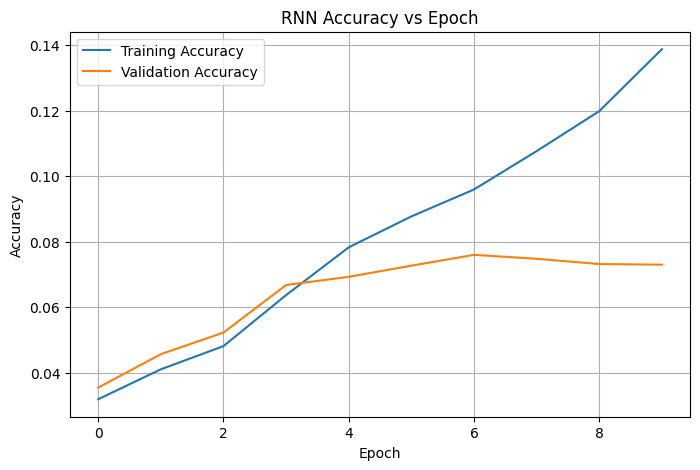

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("RNN Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

Loss vs Epoch

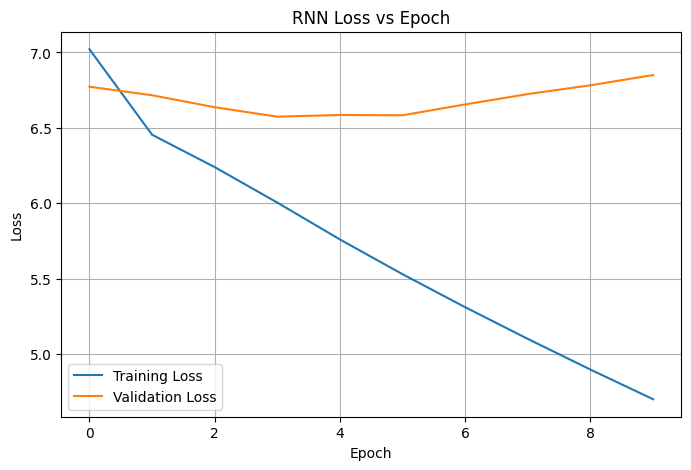

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("RNN Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

**TASK D — Text Generation**

Create the text generation function

In [23]:
def generate_text(seed_text, next_words):
    generated_text = seed_text.lower()

    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([generated_text])[0]

        token_list = token_list[-(MAX_SEQUENCE_LEN - 1):]

        token_list = tf.keras.preprocessing.sequence.pad_sequences(
            [token_list],
            maxlen=MAX_SEQUENCE_LEN - 1,
            padding="pre"
        )

        predicted_probs = model.predict(token_list, verbose=0)

        predicted_word_index = np.argmax(predicted_probs, axis=-1)[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted_word_index:
                output_word = word
                break

        if output_word == "":
            break

        generated_text += " " + output_word

    return generated_text

Generate your first text

In [25]:
import numpy as np

seed_text = "to be or not"

generated = generate_text(
    seed_text,
    next_words=20
)

print("Seed Text:")
print(seed_text)

print("\nGenerated Text:")
print(generated)

Seed Text:
to be or not

Generated Text:
to be or not in a power and his name and the duke of the king of york and i have been a man


Generate multiple samples

In [26]:
seed_texts = [
    "to be or not",
    "the king",
    "my lord",
    "what is"
]

for seed in seed_texts:
    print("=" * 70)
    print("Seed:", seed)

    generated = generate_text(
        seed,
        next_words=20
    )

    print("Generated:")
    print(generated)
    print()

Seed: to be or not
Generated:
to be or not in a power and his name and the duke of the king of york and i have been a man

Seed: the king
Generated:
the king of hereford and the moveables the king of york and i have not to be a man of the people

Seed: my lord
Generated:
my lord and will not not in the world of the people and the people are the people are the people are

Seed: what is
Generated:
what is a man of his own lord gloucester i am a man of the people and the people are the people



Generate a longer sample

In [28]:
seed_text = "the king"

generated_text = generate_text(
    seed_text,
    next_words=50
)

print("Generated Shakespeare-style Text:\n")

# Wrap the output into multiple lines
words = generated_text.split()

for i in range(0, len(words), 10):
    print(" ".join(words[i:i+10]))

Generated Shakespeare-style Text:

the king of hereford and the moveables the king of
york and i have not to be a man of
the people that i have been the king of hereford
and the people was the king of death and i
have been to the people and the people are the
king of
